<!-- # Notebook for Simulating $\hat c_j^i$ Distribution -->

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Latex

from numpy import linalg as LA
from sklearn.model_selection import train_test_split


## Configuration

In [2]:
NUM_SAMPLES = 10
NUM_FEATURES = 20
NUM_CLIENTS = 50
NUM_CLUSTERS = 2

### Hyperparameters

In [3]:
K = 100
SUBSET_SIZE = 20
alpha = 0.01

## Synthetic Linear Dataset

The function `get_data_with_tests` generates synthetic datasets to simulate a **federated learning setup** with clustered clients. It produces feature data (`X`) and labels (`y`) for multiple clients grouped into clusters, enabling the study of data heterogeneity in distributed learning scenarios.

---

### **Dataset Generation Process**

#### 1. **Cluster-Specific Weight Initialization (`w`)**
- A unique weight vector is initialized for each cluster:
  $
  w_i \sim \mathcal{U}(-2, 2)
  $
  where:
  - $ w_i $ is a weight vector of size `num_features` for the  i-th cluster.
  - This weight vector defines the linear relationship between features and labels for all clients in a given cluster.

---

#### 2. **Feature Generation (`X`)**
- For each cluster and client, feature vectors are generated from a **multivariate normal distribution**:
  $
  X_{ijk} \sim \mathcal{N}(0, 1)
  $
  where:
  - $ X_{ijk} $ is the feature vector for the i-th cluster, j-th client, and k-th sample.
  - Each vector is of size `num_features`, with all features drawn independently from a standard normal distribution.

---

#### 3. **Label Generation (`y`)**
- Labels are generated for each feature vector using a **linear model with noise**:
  $
  y_{ijk} = X_{ijk} \cdot w_i + \epsilon_k
  $
  where:
  - $ w_i$ is the weight vector specific to cluster i.
  - $\epsilon_k $ is Gaussian noise added to simulate real-world imperfections, drawn from $\mathcal{N}(0, \sigma) $, where $ \sigma $ is controlled by the `noise` parameter.
  - $ X_{ijk} \cdot w_i $ is the dot product between the feature vector and the weight vector.

---

#### 4. **Combining Local Datasets**
- Each client has its own dataset combining features and corresponding labels:
  - Features $ X_{ijk} $ and labels $ y_{ijk} $ are combined into `localdatasets` for each cluster and client.
  - Cluster assignments are tracked in `clusterassgts` to indicate which cluster a data point belongs to.

---

### **Data Partitioning**
After generating the full dataset, the function partitions it into training and test sets:
- **Training data** (`X_train`, `y_train`) and **test data** (`X_test`, `y_test`) are created by splitting the samples for each client based on the `test_size` parameter.
- The reshaping ensures that data is appropriately organized for model training and evaluation.

---

### **Outputs**
The function returns:
1. **`X_train`**: Training features for all clients across clusters.
2. **`X_test`**: Test features for all clients across clusters.
3. **`y_train`**: Training labels corresponding to `X_train`.
4. **`y_test`**: Test labels corresponding to `X_test`.
5. **`clusters`**: List indicating the cluster assignment for each data point.

---

This setup is particularly useful for simulating **federated learning environments**, where clients have distinct but structurally related data distributions, mimicking practical scenarios of non-IID (non-independent and identically distributed) data.


In [4]:
def get_data_with_tests(num_features=NUM_FEATURES, num_clusters=NUM_CLUSTERS, num_clients=NUM_CLIENTS, num_training_samples=NUM_SAMPLES, noise=0.0, test_size=0.2, val_size=0.2):
    w = np.random.uniform(0,2,(num_clusters,num_features)) # here we shape all w for all clients
    clusters = []

    X = np.zeros ((num_clusters,num_clients,num_training_samples,num_features)) 
    y = np.zeros ((num_clusters,num_clients,num_training_samples))
    for iter_cluster in range(num_clusters): 
        for iter_node in range(0, num_clients):
            X[iter_cluster, iter_node,:,:] = np.random.randn(num_training_samples, num_features)
            r = X[iter_cluster, iter_node,:,:] @ w[iter_cluster, :].reshape(-1, 1) + np.random.normal(loc=0.0, scale=noise, size=(num_training_samples, 1))
            y[iter_cluster, iter_node,:] = r.squeeze()
            clusters.append(iter_cluster)


    X = X.reshape(-1, X.shape[2], X.shape[3])
    y = y.reshape(-1, y.shape[2])
    
    X_val = X[:, :int(num_training_samples*val_size), :]
    X_test = X[:, int(num_training_samples*val_size):int(num_training_samples*(test_size+val_size)), :]
    X_train = X[:, int(num_training_samples*(val_size+test_size)):, :]
    
    y_val = y[:, :int(num_training_samples*val_size)]
    y_test = y[:, int(num_training_samples*val_size):int(num_training_samples*(test_size+val_size))]
    y_train = y[:, int(num_training_samples*(val_size+test_size)):]
    
    return X_train, X_test, X_val, y_train, y_test, y_val


## Personalized Federated Learning via Active Sampling for Non-Parametric Models


This function implements a **non-parametric optimization algorithm** for **Personalized Federated Learning (PersFL)**. It trains personalized models for individual clients (e.g., smartphones, IoT devices) by leveraging both their local data and data from a sampled subset of other clients, ensuring improved performance on non-IID (non-independent and identically distributed) data distributions.

---

### **Algorithm Overview**

#### **Objective**
The goal is to improve the personalized model for each client by:
- Sampling relevant clients’ data using **active sampling**.
- Updating model weights $
\tilde{h}^{(i')} = \arg\min_{h \in H} \left( \eta L_i(h) + \frac{1}{|D^{(t)}|} \sum_{x \in D^{(t)}} \left( h(x) - \hat{h}(x) \right)^2 \right)
$ using the combined data.
- Computing the **mean squared error (MSE)** to evaluate and refine the updates.

#### **Input**
- **`X`**, **`X_test`**: Local training and test feature data for all clients.
- **`y`**, **`y_test`**: Corresponding labels for the training and test data.
- **`clusters`**: Cluster assignments for all clients, capturing data similarity.
- **`K`**: Number of optimization iterations.
- **`subset_size`**: Number of sampled clients for active data pooling.
- **`alpha`**: Weighting factor for balancing local and external data contributions.

#### **Steps in the Algorithm**

1. **Model Initialization**:
   - A decision tree regressor (`DecisionTreeRegressor`) is initialized for each client (`h_hat`).
   - Each model is initially trained using the **test data** of the corresponding client (`X_test`, `y_test`).

2. **Active Sampling**:
   - At each iteration \( k \), for each client \( i \):
     - Randomly sample a subset of `subset_size` other clients from the pool.
     - Ensure the current client \( i \) is not included in its own subset.

3. **Weighted Model Updates**:
   - For each sampled client \( i' \), a new model is trained using both:
     - The sampled client’s data (`X[i_p]`, `y[i_p]`).
     - The current client’s test data (`X_test[i]`, `h_hat[i].predict(X_test[i])`), weighted by `alpha`.
   - **Sample Weights**:
     - A combined sample weight vector is created to balance contributions of local and external data:
     - Weights are normalized to ensure stability.

4. **Model Selection**:
   - For each sampled client \( i' \), calculate the **MSE** on the local client’s training data $ (X[i], y[i]) $.
   - Select the model that minimizes the MSE, and update the personalized model $ \hat{h}[i] $.

5. **Loss Tracking**:
   - Compute and track the MSE for the updated models across all iterations to monitor training progress.

6. **Output**:
   - **`h_hat`**: Updated models for each client.
   - **`loss_history`**: History of loss values across iterations.

---

### **Key Features**

1. **Personalized Models**:
   - A unique model is trained for each client, improving local prediction performance while respecting privacy.

2. **Active Sampling**:
   - By pooling data from a subset of clients, the algorithm mitigates the challenge of small, local datasets while maintaining personalization.

3. **Weighted Updates**:
   - The use of sample weights ensures a controlled balance between the local client’s data and pooled external data.

4. **Non-Parametric Learning**:
   - The use of decision trees as base models allows for flexibility in learning non-linear relationships in data.

---

### **Summary**
This non-parametric algorithm uses **active sampling** to refine personalized models by leveraging pooled data from relevant clients. The combination of **decision trees**, **gradient-based updates**, and **sample weighting** makes it effective for handling non-IID data distributions in federated learning setups, ensuring privacy and improved personalization.


In [5]:
def mean_squared_error(pred_y, true_y):
    # Computes the MSE between actual labels and the predicted labels
    m = len(true_y)
    mse = (1 / m) * np.sum((pred_y - true_y) ** 2)
    return mse

def bulk_mean_squared_error(pred_y, true_y):
    # Computes the MSE for multiple model's parameters.
    m = len(true_y)
    mse = (1 /  m) * np.sum((pred_y - true_y)**2, axis=1)
    return mse

def gradient(theta, X, y):
    # Computes the gradient of the cost function (MSE)
    m = len(y)
    gradient = (2 / m) * X.T.dot(X.dot(theta) - y)
    return gradient

def bulk_gradient(theta, X, y):
    # Computes gradients for multiple model's parameters
    array1 = X
    array2 = X.dot(theta) - y
    result = np.einsum('ijk,ij->ik', array1, array2)
    return result
    

In [6]:
from sklearn import tree

def non_parametric_algorithm(X, X_test, X_val, y, y_test, y_val, K, subset_size, alpha, max_depth=1, first_iter='train'):
    N = len(X)
    nodes = [i for i in range(N)]
    
    
    h_hat = [tree.DecisionTreeRegressor(max_depth=max_depth) for i in range(N)]
    
    loss_history = []
    
    for k in range(K):
        loss = []
        for i in range(N):
            if i != 0:
                continue
            if k == 0:
                if first_iter == 'train':
                    h_hat[i].fit(X[i], y[i])
                elif first_iter == 'test':
                    h_hat[i].fit(X_test[i], y_test[i])
                elif first_iter == 'val':
                    h_hat[i].fit(X_val[i], y_val[i])
                loss.append(mean_squared_error(h_hat[i].predict(X_val[i]), y_val[i]))
                continue
                
            # Select neighbors (a subset of other nodes)
            all_nodes = [node for node in range(N) if node != i]
            selected_nodes = random.sample(all_nodes, min(subset_size, len(all_nodes)))
            
            _losses = []
            tilde_h = []
            for i_p in selected_nodes:
                new_model = tree.DecisionTreeRegressor(max_depth=max_depth)
                sample_weights = np.concatenate([np.ones_like(y[i_p]) * alpha] + [np.ones_like(y_test[i])])
                normalized_weights = sample_weights * (len(sample_weights) / sum(sample_weights))
                combined_X = np.concatenate([X[i_p], X_test[i]])
                combined_y = np.concatenate([y[i_p], h_hat[i].predict(X_test[i])])
                new_model.fit(combined_X, combined_y, sample_weight=normalized_weights)
                _loss = mean_squared_error(new_model.predict(X[i]), y[i])
                _losses.append(_loss)
                tilde_h.append(new_model)
                
            
            best_h = tilde_h[np.argmin(_losses)]

            h_hat[i] = best_h   
             
            loss.append(mean_squared_error(h_hat[i].predict(X_val[i]), y_val[i]))
        
        loss_history.append(np.mean(loss))

    # print(y[0], h_hat[0].predict(X[0]))
            
    return h_hat, loss_history

In [7]:
X_train, X_test, X_val, y_train, y_test, y_val = get_data_with_tests(num_training_samples=NUM_SAMPLES*5, test_size=0.3, val_size=0.3)
print(X_train[0].shape, X_test[0].shape, X_val[0].shape)
h_hat, loss_dm_algo = non_parametric_algorithm(X_train, X_test, X_val, y_train, y_test, y_val, K, SUBSET_SIZE, alpha=0.1)


(20, 20) (15, 20) (15, 20)


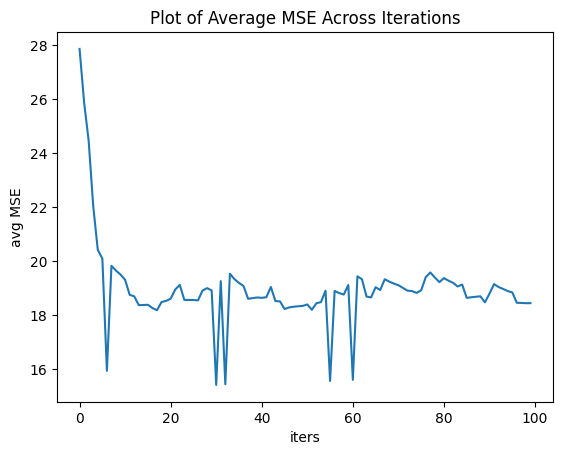

In [8]:
plt.plot([i for i in range(len(loss_dm_algo))], loss_dm_algo)
# plt.yscale('log')
plt.xlabel('iters')
plt.ylabel('avg MSE')

# plt.legend()
plt.title(f"Plot of Average MSE Across Iterations")
plt.show()

In [9]:
def ExtractFeatureMatrixLabvelVector(data):
    """Extracts feature matrix and label vector from FMI weather data.

    Parameters
    ----------
    data : pandas.DataFrame
        DataFrame containing columns "Latitude", "Longitude", "temp", "Timestamp".
    
    Returns
    -------
    X : numpy.ndarray
        Feature matrix where each row corresponds to a data point.
    y : numpy.ndarray
        Label vector where each entry corresponds to the temperature value of a data point.
    """
    # Extract temperature and normalize the latitude and longitude
    temps = data['temp'].values
    latitudes = data['Latitude'].values / 100
    longitudes = data['Longitude'].values / 100

    # Extract time-based features (year, month, day, hour, minute)
    timestamps = pd.to_datetime(data['Timestamp'])
    year = timestamps.dt.year / 2025
    month = timestamps.dt.month / 13
    day = timestamps.dt.day / 32
    hour = timestamps.dt.hour / 25
    minute = timestamps.dt.minute / 61

    # Combine features into the feature matrix
    X = np.column_stack([latitudes, longitudes, year, month, day, hour, minute])
    y = temps.reshape(-1, 1)

    return X, y

def get_FMI_data(test_size=0.2, val_size=0.2):
    data = pd.read_csv('~/Downloads/FMI_data.csv')
    n_stations = len(data.name.unique())
    X_train = []
    X_test = []
    X_val = []
    y_train = [] 
    y_test = []
    y_val = []
    
    for i, station in enumerate(data.name.unique()):
        # Extract data of a certain station
        station_data = data[data.name==station]
        
        # Extract features and labels
        X, y = ExtractFeatureMatrixLabvelVector(station_data)
        
        # Split the dataset into training and validation set. 
        _X_train_test, _X_val, _y_train_test, _y_val = train_test_split(X, y, test_size=val_size, random_state=1)
        _X_train, _X_test, _y_train, _y_test = train_test_split(_X_train_test, _y_train_test, test_size=test_size/(1-val_size), random_state=1)

        X_train.append(_X_train)
        X_test.append(_X_test)
        X_val.append(_X_val)
        y_train.append(_y_train.ravel())
        y_test.append(_y_test.ravel())
        y_val.append(_y_val.ravel())

    return X_train, X_test, X_val, y_train, y_test, y_val


In [10]:
X_train, X_test, X_val, y_train, y_test, y_val = get_FMI_data(test_size=0.3, val_size=0.3)
print(len(X_train), X_train[0].shape, X_test[0].shape, X_val[0].shape)

207 (38, 7) (29, 7) (29, 7)


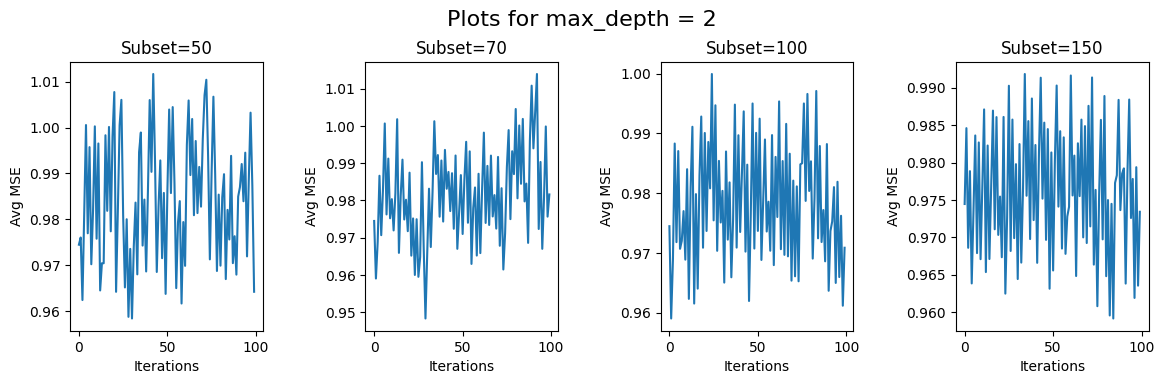

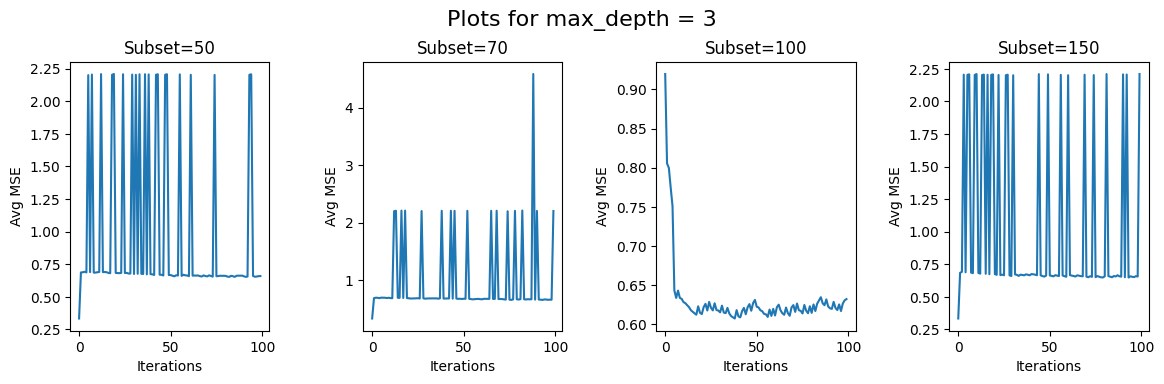

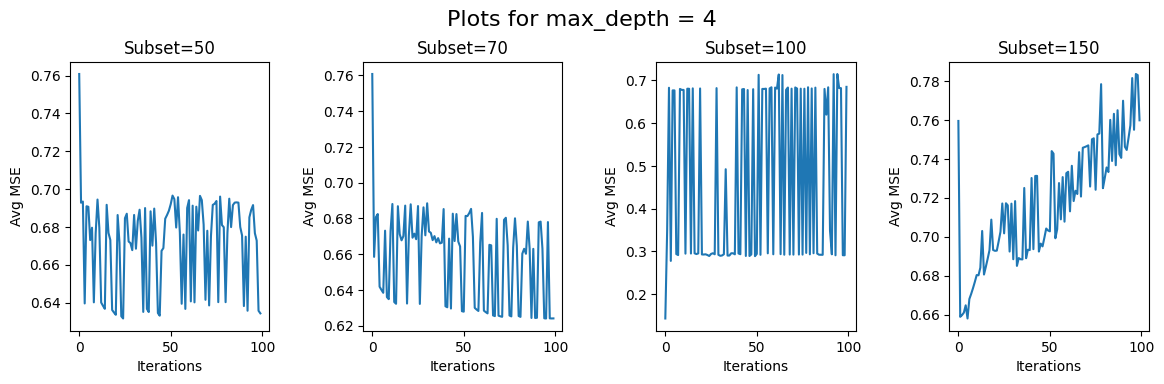

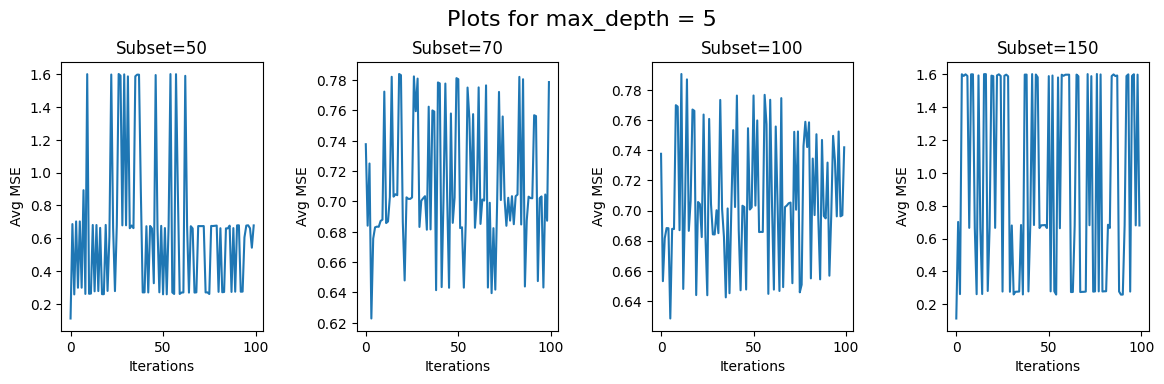

In [13]:
plots_per_row = 4

# Define the parameters for plotting
max_depths = [2, 3, 4, 5]
subset_sizes = [50, 70, 100, 150]

# Loop through max_depths
for max_depth in max_depths:
    # Set up the subplots
    fig, axes = plt.subplots(
        nrows=(len(subset_sizes) + plots_per_row - 1) // plots_per_row, 
        ncols=plots_per_row, 
        squeeze=False,
        figsize = (12, 4)
    )
    
    # Add a suptitle for the entire figure
    fig.suptitle(f"Plots for max_depth = {max_depth}", fontsize=16)
    
    # Flatten the axes for easier indexing
    axes = axes.flatten()
    
    # Loop through subset_sizes
    for idx, subset_size in enumerate(subset_sizes):
        h_hat, loss_dm_algo = non_parametric_algorithm(
            X_train, X_test, X_val, y_train, y_test, y_val, K, subset_size, alpha=0.01, 
            max_depth=max_depth, first_iter='train'
        )
        
        ax = axes[idx]
        ax.plot([i for i in range(len(loss_dm_algo))], loss_dm_algo)
        ax.set_xlabel('Iterations')
        ax.set_ylabel('Avg MSE')
        ax.set_title(f"Subset={subset_size}")
    
    # Hide any unused subplots
    for idx in range(len(subset_sizes), len(axes)):
        axes[idx].axis('off')
    
    # Adjust the layout to ensure space between the suptitle and small plot titles
    plt.tight_layout(pad=2.0)  # Add padding between plots
    plt.subplots_adjust(top=0.85)  # Adjust the position of the suptitle
    plt.show()